In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
from datetime import datetime
from datetime import date
from pandas import Series, DataFrame
from glob import glob

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
#more = pd.read_excel('/content/drive/MyDrive/E7企業專案相關/all_data/3_more/3more_all.xlsx')
#xin = pd.read_csv('/content/drive/MyDrive/E7企業專案相關/all_data/Xin/xin.csv')
#triple = pd.read_csv('/content/drive/MyDrive/E7企業專案相關/all_data/triple/triple_all.csv')

In [ ]:
more = pd.read_csv('/content/drive/MyDrive/E7play_pre/3more_all.csv')
xin = pd.read_csv('/content/drive/MyDrive/E7play_pre/xin.csv')
triple = pd.read_csv('/content/drive/MyDrive/E7play_pre/triple_all.csv')

# **小處理個別資料**

In [ ]:
triple = triple.loc[:,["編號","單品名稱","售單價","實單價","數量","金額","收項時間","類別名稱","firstdate","lastdate"]]#只取部分行
triple = triple.rename(columns={"編號":"id","firstdate": "FD","lastdate":"LD"})
triple

,id,單品名稱,售單價,實單價,數量,金額,收項時間,類別名稱,FD,LD
0,34769.0,七獎換點數,0.0,0.0,1.0,0.0,2015-01-01 00:17:00,刮刮卡,2014-09-08 00:00:00,2016-08-03 00:00:00
1,34769.0,七獎換點數,0.0,0.0,1.0,0.0,2015-01-01 00:17:00,刮刮卡,2014-09-08 00:00:00,2016-08-03 00:00:00
2,34769.0,七獎換點數,0.0,0.0,1.0,0.0,2015-01-01 00:17:00,刮刮卡,2014-09-08 00:00:00,2016-08-03 00:00:00
3,34769.0,七獎換點數,0.0,0.0,1.0,0.0,2015-01-01 00:17:00,刮刮卡,2014-09-08 00:00:00,2016-08-03 00:00:00
4,34769.0,七獎換點數,0.0,0.0,1.0,0.0,2015-01-01 00:17:00,刮刮卡,2014-09-08 00:00:00,2016-08-03 00:00:00
...,...,...,...,...,...,...,...,...,...,...
309711,70008550.0,午晚3小時入場票-假,270.0,267.0,2.0,534.0,2021-05-14 18:13:00,假日票券,2020-09-15 00:00:00,2022-02-16 00:00:00
309712,604762.0,點數升級金卡,0.0,0.0,1.0,0.0,2021-05-14 20:04:00,會員卡,2017-11-30 00:00:00,2022-06-23 00:00:00
309713,604762.0,收APP生日券,0.0,0.0,1.0,0.0,2021-05-14 20:05:00,其它票券,2017-11-30 00:00:00,2022-06-23 00:00:00
309714,604762.0,5小時生日券(紅金),0.0,0.0,1.0,0.0,2021-05-14 20:05:00,其它票券,2017-11-30 00:00:00,2022-06-23 00:00:00


In [ ]:
xin = xin.rename(columns={"firstdate": "FD","最後消費日期":"LD","Unnamed: 8":"金額","Unnamed: 12":"收項時間"})
xin = xin.loc[:,["id","金額","收項時間","FD","LD"]]
xin

,id,金額,收項時間,FD,LD
0,301283,10.0,2015-03-07 11:53:00,2015-01-02,2015-03-07
1,301283,287.0,2015-03-07 11:53:00,2015-01-02,2015-03-07
2,301283,10.0,2015-01-31 10:41:00,2015-01-02,2015-03-07
3,301283,287.0,2015-01-31 10:41:00,2015-01-02,2015-03-07
4,301283,10.0,2015-01-12 16:25:00,2015-01-02,2015-03-07
...,...,...,...,...,...
22350,304198,188.0,2021-04-21 16:18:00,2021-04-21 00:00:00,2021-04-21
22351,304198,0.0,2021-04-21 15:52:00,2021-04-21 00:00:00,2021-04-21
22352,304199,376.0,2021-04-22 20:52:00,2021-04-22 00:00:00,2021-04-22
22353,70020342,1526.0,2021-04-28 19:52:00,2021-04-28 00:00:00,2021-04-28


In [ ]:
more

,No,FD,LD,Sexual,單品名稱,收項時間,類別名稱,金額,數量,折扣,來客天數,銷售淨額,折扣級別,有效日期,BD,age
0,50000127,2015-01-02 00:00:00,2022-10-29 00:00:00,男,早上90分鐘入場票-假,2015-01-02 08:40:29,假日票券,153.0,1,10,28,19225,2,NaN,1995-11-29 00:00:00,27.0
1,50000127,2015-01-02 00:00:00,2022-10-29 00:00:00,男,早上5小時入場票-平,2015-02-05 11:06:14,平日票券,684.0,4,10,28,19225,2,NaN,1995-11-29 00:00:00,27.0
2,50000127,2015-01-02 00:00:00,2022-10-29 00:00:00,男,早上5小時入場票-平,2015-02-12 09:34:47,平日票券,342.0,2,10,28,19225,2,NaN,1995-11-29 00:00:00,27.0
3,50000127,2015-01-02 00:00:00,2022-10-29 00:00:00,男,平-早上5小時貴賓券-平,2015-02-12 09:34:59,其它票券,0.0,1,0,28,19225,2,NaN,1995-11-29 00:00:00,27.0
4,50000127,2015-01-02 00:00:00,2022-10-29 00:00:00,男,午晚3小時入場票-假,2015-05-02 17:57:17,假日票券,1800.0,8,10,28,19225,2,NaN,1995-11-29 00:00:00,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357252,70021019,2021-05-10 00:00:00,2021-05-11 00:00:00,男,+20元無限暢飲,2021-05-11 20:43:21,活動,60.0,4,0,1,1516,7,NaN,1994-04-05 00:00:00,29.0
357253,70021046,2021-05-12 00:00:00,2022-09-10 00:00:00,男,七獎-20點,2021-05-12 00:45:24,刮刮卡,0.0,1,0,2,990,7,NaN,1992-12-14 00:00:00,30.0
357254,70021079,2021-05-13 00:00:00,2021-05-13 00:00:00,男,午晚3小時入場票-平,2021-05-13 12:32:29,平日票券,416.0,2,10,1,416,7,NaN,1998-11-12 00:00:00,24.0
357255,70021102,2021-05-13 00:00:00,2022-08-27 00:00:00,男,午晚3小時入場票-假,2021-05-14 21:45:06,假日票券,992.0,4,10,3,4040,7,NaN,1998-10-24 00:00:00,24.0


In [ ]:
triple['FD'] = pd.to_datetime(triple['FD'], format='%Y/%m/%d', errors='coerce')
triple['LD'] = pd.to_datetime(triple['LD'], format='%Y/%m/%d', errors='coerce')
triple['收項時間'] = pd.to_datetime(triple['收項時間'], format='%Y/%m/%d', errors='coerce')
xin['FD'] = pd.to_datetime(xin['FD'], format='%Y/%m/%d', errors='coerce')
xin['LD'] = pd.to_datetime(xin['LD'], format='%Y/%m/%d', errors='coerce')
xin['收項時間'] = pd.to_datetime(xin['收項時間'], format='%Y/%m/%d', errors='coerce')
more['收項時間'] = pd.to_datetime(more['收項時間'], format='%Y/%m/%d', errors='coerce')

# **計算總金額**
https://pythonviz.com/pandas/pandas-groupby-tutorial/

In [ ]:
#total cunsumption
xin_tm = xin.groupby(by=['id']).agg({'金額': sum})
triple_tm = triple.groupby(by=['id']).agg({'金額': sum})
more_tm = more.groupby(by=['No']).agg({'金額': sum})

In [ ]:
xin_tm = xin_tm.dropna(subset=['金額'])
triple_tm = triple_tm.dropna(subset=['金額'])
more_tm = more_tm.dropna(subset=['金額'])

xin_tm = xin_tm.loc[(xin_tm['金額'] != 0)]
triple_tm = triple_tm.loc[(triple_tm['金額'] != 0)]
more_tm = more_tm.loc[(more_tm['金額'] != 0)]

In [ ]:
print(xin_tm)
print(triple_tm)
print(more_tm)

                金額
id                
300018    1675.000
300069     504.999
300116    2745.001
300124      80.000
300171    1054.000
...            ...
70019153   801.000
70019560   496.000
70019574  1105.000
70020342  1526.000
70020812   476.000

[2103 rows x 1 columns]
                金額
id                
3015.0      3972.0
4067.0       218.0
4068.0      2271.0
4446.0       198.0
13700.0      100.0
...            ...
70020818.0   376.0
70020904.0   228.0
70020954.0   208.0
70021069.0   120.0
70021099.0   180.0

[17719 rows x 1 columns]
               金額
No               
50000127  19225.0
50000128   8104.0
50000129   2319.0
50000130   3258.0
50000131   2402.0
...           ...
70021014    366.0
70021019   1516.0
70021079    416.0
70021102    992.0
70021112    496.0

[15130 rows x 1 columns]


# **來店次數**

In [ ]:
xin['收項時間'] = pd.to_datetime(xin['收項時間'], format='%Y-%m-%d %H:%M:%S')
xin["duration"] = xin.sort_values(['id','收項時間']).groupby('id')['收項時間'].diff()#先以id排序再以收項時間排
triple["duration"] = triple.sort_values(['id','收項時間']).groupby('id')['收項時間'].diff()
more["duration"] = more.sort_values(['No','收項時間']).groupby('No')['收項時間'].diff()
xin


,id,金額,收項時間,FD,LD,duration
0,301283,10.0,2015-03-07 11:53:00,2015-01-02,2015-03-07,35 days 01:12:00
1,301283,287.0,2015-03-07 11:53:00,2015-01-02,2015-03-07,0 days 00:00:00
2,301283,10.0,2015-01-31 10:41:00,2015-01-02,2015-03-07,7 days 13:49:00
3,301283,287.0,2015-01-31 10:41:00,2015-01-02,2015-03-07,0 days 00:00:00
4,301283,10.0,2015-01-12 16:25:00,2015-01-02,2015-03-07,2 days 20:05:00
...,...,...,...,...,...,...
22350,304198,188.0,2021-04-21 16:18:00,2021-04-21,2021-04-21,0 days 00:26:00
22351,304198,0.0,2021-04-21 15:52:00,2021-04-21,2021-04-21,0 days 00:10:00
22352,304199,376.0,2021-04-22 20:52:00,2021-04-22,2021-04-22,NaT
22353,70020342,1526.0,2021-04-28 19:52:00,2021-04-28,2021-04-28,NaT


In [ ]:
xin_f = xin[xin["duration"] > pd.Timedelta(days=1)].groupby('id').size().reset_index(name='來店次數')
triple_f = triple[triple["duration"] > pd.Timedelta(days=1)].groupby('id').size().reset_index(name='來店次數')
more_f = more[more["duration"] > pd.Timedelta(days=1)].groupby('No').size().reset_index(name='來店次數')

xin_f = xin_f.set_index('id', drop=False)
triple_f = triple_f.set_index('id', drop=False)
more_f = more_f.set_index('No', drop=False)

xin_f = xin_f.rename_axis('index_id')
triple_f = triple_f.rename_axis('index_id')
more_f = more_f.rename_axis('index_No')

xin_f = xin_f.dropna(subset=['來店次數'])
triple_f = triple_f.dropna(subset=['來店次數'])
more_f = more_f.dropna(subset=['來店次數'])

xin_f
triple_f

,id,來店次數
index_id,,
3015.0,3015.0,3
4068.0,4068.0,7
16594.0,16594.0,8
17713.0,17713.0,1
17790.0,17790.0,7
...,...,...
70020310.0,70020310.0,2
70020322.0,70020322.0,1
70020622.0,70020622.0,1


In [ ]:
id_counts = xin['id'].value_counts()
single_occurrence_ids=id_counts[id_counts == 1].index
xin_a = xin[xin['id'].isin(single_occurrence_ids)].drop_duplicates(subset='id').copy()
xin_a = xin_a.set_index('id', drop=False)
xin_a = xin_a.rename_axis('index_id')
xin_a['來店次數'] = 1
xin_a=xin_a.drop('金額', axis=1)
xin_a=xin_a.drop('收項時間', axis=1)
xin_a=xin_a.drop('FD', axis=1)
xin_a=xin_a.drop('LD', axis=1)
xin_a=xin_a.drop('duration', axis=1)
xin_f = pd.concat([xin_f, xin_a])
xin_f

,id,來店次數
index_id,,
300018,300018,1
300116,300116,2
300171,300171,1
300250,300250,4
300260,300260,4
...,...,...
304183,304183,1
70018055,70018055,1
304199,304199,1


In [ ]:
id_counts = triple['id'].value_counts()
single_occurrence_ids=id_counts[id_counts == 1].index
triple_a = triple[triple['id'].isin(single_occurrence_ids)].drop_duplicates(subset='id').copy()#.reset_index(drop=True)
triple_a = triple_a.set_index('id', drop=False)
triple_a = triple_a.rename_axis('index_id')
triple_a['來店次數'] = 1
triple_a=triple_a.drop('金額', axis=1)
triple_a=triple_a.drop('收項時間', axis=1)
triple_a=triple_a.drop('FD', axis=1)
triple_a=triple_a.drop('LD', axis=1)
triple_a=triple_a.drop('duration', axis=1)
triple_a=triple_a.drop('單品名稱', axis=1)
triple_a=triple_a.drop('售單價', axis=1)
triple_a=triple_a.drop('實單價', axis=1)
triple_a=triple_a.drop('數量', axis=1)
triple_a=triple_a.drop('類別名稱', axis=1)
triple_f = pd.concat([triple_f, triple_a])
triple_f

,id,來店次數
index_id,,
3015.0,3015.0,3
4068.0,4068.0,7
16594.0,16594.0,8
17713.0,17713.0,1
17790.0,17790.0,7
...,...,...
70013184.0,70013184.0,1
70009937.0,70009937.0,1
70020904.0,70020904.0,1


In [ ]:
id_counts = more['No'].value_counts()
single_occurrence_ids=id_counts[id_counts == 1].index
more_a = more[more['No'].isin(single_occurrence_ids)].drop_duplicates(subset='No').copy()
more_a = more_a.set_index('No', drop=False)
more_a = more_a.rename_axis('index_id')
more_a['來店次數'] = 1
more_a=more_a.drop('金額', axis=1)
more_a=more_a.drop('收項時間', axis=1)
more_a=more_a.drop('FD', axis=1)
more_a=more_a.drop('LD', axis=1)
more_a=more_a.drop('duration', axis=1)
more_a=more_a.drop('Sexual', axis=1)
more_a=more_a.drop('單品名稱', axis=1)
more_a=more_a.drop('類別名稱', axis=1)
more_a=more_a.drop('數量', axis=1)
more_a=more_a.drop('折扣', axis=1)
more_a=more_a.drop('來客天數', axis=1)
more_a=more_a.drop('銷售淨額', axis=1)
more_a=more_a.drop('折扣級別', axis=1)
more_a=more_a.drop('有效日期', axis=1)
more_a=more_a.drop('BD', axis=1)
more_a=more_a.drop('age', axis=1)
more_f = pd.concat([more_f, more_a])
more_f

,No,來店次數
50000127,50000127,26
50000128,50000128,10
50000129,50000129,2
50000130,50000130,2
50000131,50000131,3
...,...,...
70020880,70020880,1
70021046,70021046,1
70021079,70021079,1
70021102,70021102,1


# **直方圖(縱軸:人數/橫軸:金額)**

***##平均金額***

In [ ]:
xin_tm_f = pd.merge(xin_tm, xin_f, on='id')
triple_tm_f = pd.merge(triple_tm, triple_f, on='id')
more_tm_f = pd.merge(more_tm, more_f, on='No')
xin_tm_f['average']=xin_tm_f['金額']/xin_tm_f['來店次數']
triple_tm_f['average']=triple_tm_f['金額']/triple_tm_f['來店次數']
more_tm_f['average']=more_tm_f['金額']/more_tm_f['來店次數']



> 新莊館



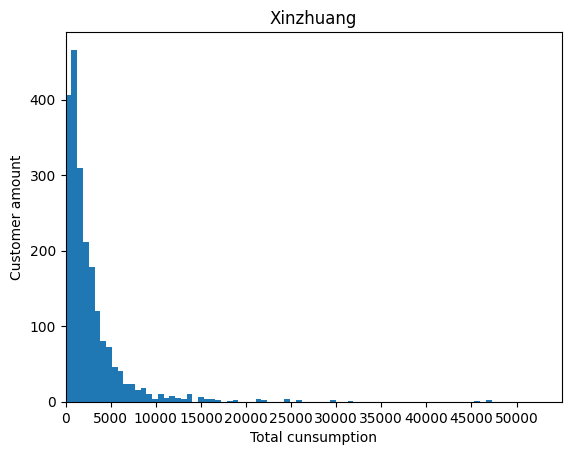

In [ ]:
#累積金額
plt.hist(xin_tm,bins=130)#大概20個人一組
plt.xticks(range(0, 55000, 5000))
plt.xlim(0, 55000)
plt.title("Xinzhuang")
plt.xlabel("Total cunsumption")
plt.ylabel("Customer amount")
plt.show()

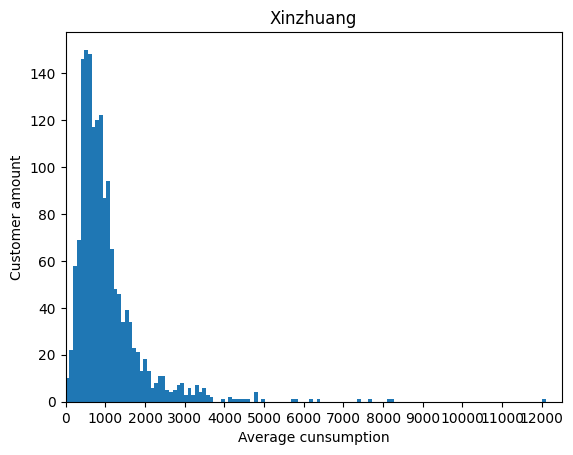

In [ ]:
#平均金額
plt.hist(xin_tm_f['average'],bins=130)#大概20個人一組
plt.xticks(range(0, 12500, 1000))
plt.xlim(0, 12500)
plt.title("Xinzhuang")
plt.xlabel("Average cunsumption")
plt.ylabel("Customer amount")
plt.show()



> 三重館



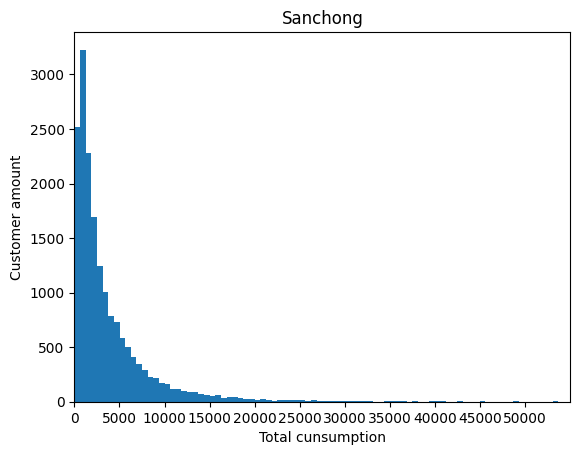

In [ ]:
#累積金額
plt.hist(triple_tm,bins=1000)
plt.xticks(range(0, 55000, 5000))
plt.xlim(0, 55000)
plt.title("Sanchong")
plt.xlabel("Total cunsumption")
plt.ylabel("Customer amount")
plt.show()

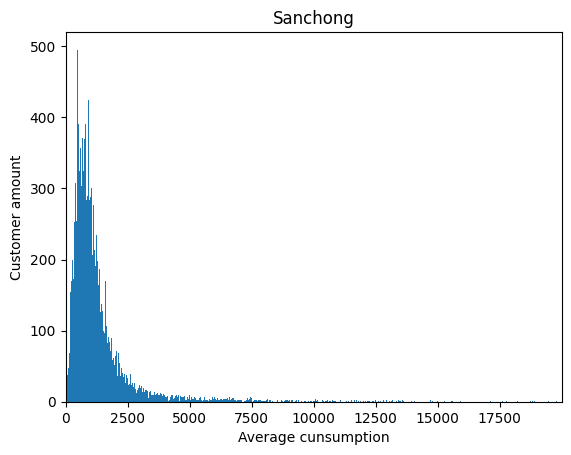

In [ ]:
#平均金額
plt.hist(triple_tm_f['average'],bins=1000)
plt.xticks(range(0, 20000, 2500))
plt.xlim(0, 20000)
plt.title("Sanchong")
plt.xlabel("Average cunsumption")
plt.ylabel("Customer amount")
plt.show()



> 三多館



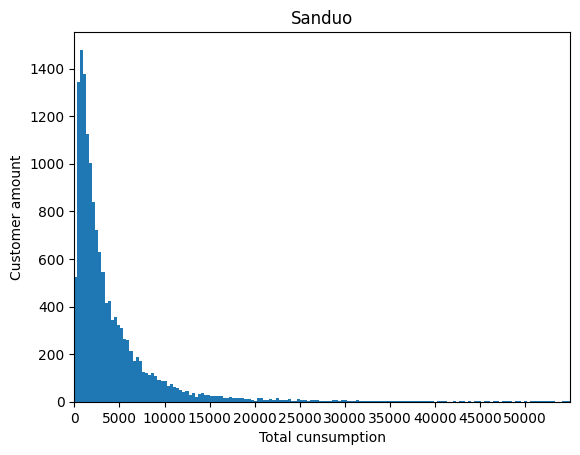

In [ ]:
#累積金額
plt.hist(more_tm,bins=770)
plt.xticks(range(0, 55000, 5000))
plt.xlim(0, 55000)
plt.title("Sanduo")
plt.xlabel("Total cunsumption")
plt.ylabel("Customer amount")
plt.show()

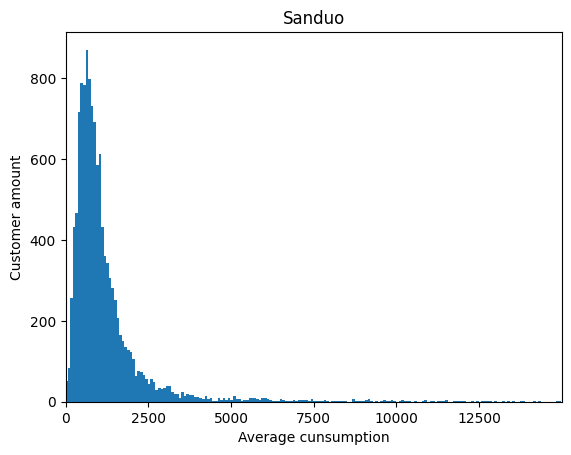

In [ ]:
#平均金額
plt.hist(more_tm_f['average'],bins=770)
plt.xticks(range(0, 15000, 2500))
plt.xlim(0, 15000)
plt.title("Sanduo")
plt.xlabel("Average cunsumption")
plt.ylabel("Customer amount")
plt.show()

**三館消費分布無明顯差異**

***##次數-金額散佈圖(暫停中)***

In [ ]:
xin_tm

,金額
id,
300018,1675.000
300069,504.999
300116,2745.001
300124,80.000
300171,1054.000
...,...
70019153,801.000
70019560,496.000
70019574,1105.000


In [ ]:
xin_f['來店次數']

index_id
300018      1
300116      2
300171      1
300250      4
300260      4
           ..
304183      1
70018055    1
304199      1
70020342    1
70020812    1
Name: 來店次數, Length: 2117, dtype: int64

In [ ]:
#import matplotlib.pyplot as plt
#plt.scatter(xin_tm, xin_f['來店次數'])
#plt.xlabel('消费额')
#plt.ylabel('次数')
#plt.title('消费额与次数四分位距的散点图')
#plt.show()


***##來店次數斷層***




> 新莊館



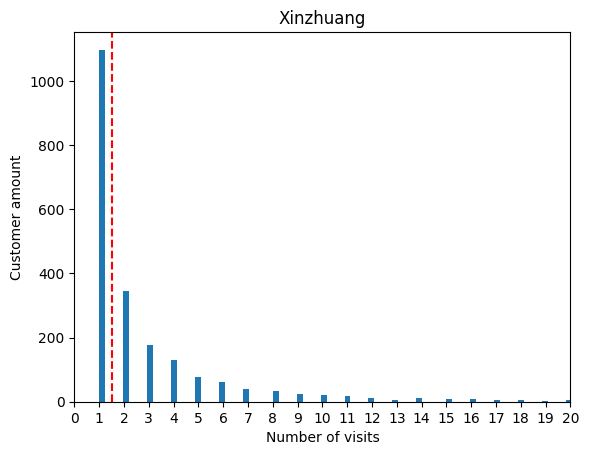

In [ ]:
import matplotlib.pyplot as plt

plt.hist(xin_f['來店次數'],bins=800)
plt.xticks(range(0, 200, 1))
plt.xlim(0, 20)#斷層只出現在前面 不需要顯現太多個
plt.title("Xinzhuang")
plt.xlabel("Number of visits")
plt.ylabel("Customer amount")
plt.axvline(x=1.5, color='red', linestyle='--')
plt.show()



> 三重館



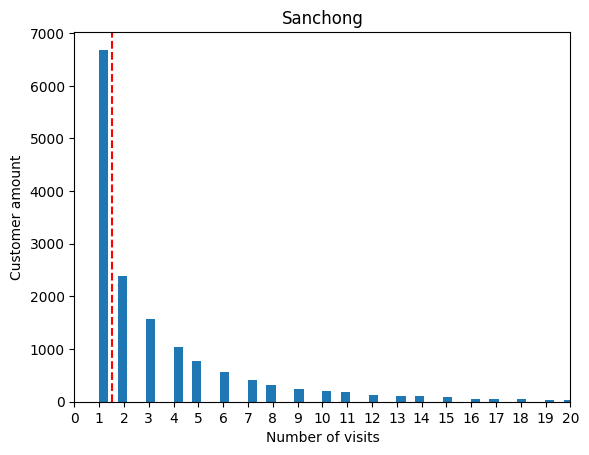

In [ ]:
import matplotlib.pyplot as plt

plt.hist(triple_f['來店次數'],bins=2000)
plt.xticks(range(0, 1800, 1))
plt.xlim(0, 20)#斷層只出現在前面 不需要顯現太多個
plt.title("Sanchong")
plt.xlabel("Number of visits")
plt.ylabel("Customer amount")
plt.axvline(x=1.5, color='red', linestyle='--')
plt.show()



> 三多館




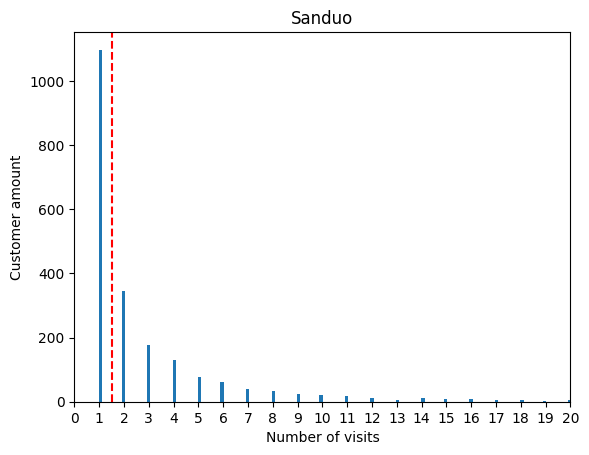

In [ ]:
import matplotlib.pyplot as plt

plt.hist(xin_f['來店次數'],bins=1500)
plt.xticks(range(0, 200, 1))
plt.xlim(0, 20)#斷層只出現在前面 不需要顯現太多個
plt.title("Sanduo")
plt.xlabel("Number of visits")
plt.ylabel("Customer amount")
plt.axvline(x=1.5, color='red', linestyle='--')
plt.show()

**三館皆是來店次數[一次]產生斷層**

**##拉出第一群**



> 新莊館



In [ ]:
xin_f

,id,來店次數
index_id,,
300018,300018,1
300116,300116,2
300171,300171,1
300250,300250,4
300260,300260,4
...,...,...
304183,304183,1
70018055,70018055,1
304199,304199,1


In [ ]:
xin

,id,金額,收項時間,FD,LD,duration
0,301283,10.0,2015-03-07 11:53:00,2015-01-02,2015-03-07,35 days 01:12:00
1,301283,287.0,2015-03-07 11:53:00,2015-01-02,2015-03-07,0 days 00:00:00
2,301283,10.0,2015-01-31 10:41:00,2015-01-02,2015-03-07,7 days 13:49:00
3,301283,287.0,2015-01-31 10:41:00,2015-01-02,2015-03-07,0 days 00:00:00
4,301283,10.0,2015-01-12 16:25:00,2015-01-02,2015-03-07,2 days 20:05:00
...,...,...,...,...,...,...
22350,304198,188.0,2021-04-21 16:18:00,2021-04-21,2021-04-21,0 days 00:26:00
22351,304198,0.0,2021-04-21 15:52:00,2021-04-21,2021-04-21,0 days 00:10:00
22352,304199,376.0,2021-04-22 20:52:00,2021-04-22,2021-04-22,NaT
22353,70020342,1526.0,2021-04-28 19:52:00,2021-04-28,2021-04-28,NaT


In [ ]:
xin_f_1=xin_f[xin_f['來店次數'] < 2]
xin_1 = xin[xin['id'].isin(xin_f_1['id'])]
xin_1
xin=xin[-(xin['id'].isin(xin_f_1['id']))]
xin

,id,金額,收項時間,FD,LD,duration
0,301283,10.0,2015-03-07 11:53:00,2015-01-02,2015-03-07,35 days 01:12:00
1,301283,287.0,2015-03-07 11:53:00,2015-01-02,2015-03-07,0 days 00:00:00
2,301283,10.0,2015-01-31 10:41:00,2015-01-02,2015-03-07,7 days 13:49:00
3,301283,287.0,2015-01-31 10:41:00,2015-01-02,2015-03-07,0 days 00:00:00
4,301283,10.0,2015-01-12 16:25:00,2015-01-02,2015-03-07,2 days 20:05:00
...,...,...,...,...,...,...
22347,304198,2180.0,2021-04-21 15:34:00,2021-04-21,2021-04-21,0 days 00:00:00
22348,304198,135.0,2021-04-21 15:34:00,2021-04-21,2021-04-21,0 days 00:00:00
22349,304198,436.0,2021-04-21 15:42:00,2021-04-21,2021-04-21,0 days 00:08:00
22350,304198,188.0,2021-04-21 16:18:00,2021-04-21,2021-04-21,0 days 00:26:00




> 三重館



In [ ]:
triple_f_1=triple_f[triple_f['來店次數'] < 2]
triple_1 = triple[triple['id'].isin(triple_f_1['id'])]
triple=triple[-(triple['id'].isin(triple_f_1['id']))]



> 三多館



In [ ]:
more_f_1=more_f[more_f['來店次數'] < 2]
more_1 = more[more['No'].isin(more_f_1['No'])]
more=more[-(more['No'].isin(more_f_1['No']))]

# **次數四分位距**



> 新莊館



In [ ]:
q1 = np.percentile(xin_f['來店次數'], 25)
q2 = np.percentile(xin_f['來店次數'], 50)
q3 = np.percentile(xin_f['來店次數'], 75)
q4 = np.percentile(xin_f['來店次數'], 100)
iqr = q3 - q1
print('Xinzhuang')
print("Q1:", q1)
print("Q2:", q2)
print("Q3:", q3)
print("Q4:", q4)
print("IQR:", iqr)

Xinzhuang
Q1: 1.0
Q2: 1.0
Q3: 3.0
Q4: 194.0
IQR: 2.0




> 三重館



In [ ]:
q1 = np.percentile(triple_f['來店次數'], 25)
q3 = np.percentile(triple_f['來店次數'], 75)
q2 = np.percentile(triple_f['來店次數'], 50)
q4 = np.percentile(triple_f['來店次數'], 100)
iqr = q3 - q1
print('Sanchong')
print("Q1:", q1)
print("Q2:", q2)
print("Q3:", q3)
print("Q4:", q4)
print("IQR:", iqr)

Sanchong
Q1: 1.0
Q2: 2.0
Q3: 4.0
Q4: 750.0
IQR: 3.0




> 三多館







In [ ]:
q1 = np.percentile(more_f['來店次數'], 25)
q3 = np.percentile(more_f['來店次數'], 75)
q2 = np.percentile(more_f['來店次數'], 50)
q4 = np.percentile(more_f['來店次數'], 100)
iqr = q3 - q1
print('Sanduo')
print("Q1:", q1)
print("Q2:", q2)
print("Q3:", q3)
print("Q4:", q4)
print("IQR:", iqr)

Sanduo
Q1: 1.0
Q2: 3.0
Q3: 6.0
Q4: 591.0
IQR: 5.0


# **計算間隔時間標準差&來店次數**
https://blog.csdn.net/weixin_45914452/article/details/124745960
https://www.qiniu.com/qfans/qnso-40804265#comments


In [ ]:
# xin.收項時間 = xin.收項時間.map(lambda x:datetime.striptime(x, "%Y/%m/%d %H:%M:%S"))

xin["duration"] = xin.sort_values(['id','收項時間']).groupby('id')['收項時間'].diff()#先以id排序再以收項時間排
triple["duration"] = triple.sort_values(['id','收項時間']).groupby('id')['收項時間'].diff()
more["duration"] = more.sort_values(['No','收項時間']).groupby('No')['收項時間'].diff()

# df.time = df.sort_values(['id','time']).groupby('id')['time'].diff()
# df = df.dropna(subset=['time'])
# print (df)


In [ ]:
xin_f = xin[xin["duration"] > pd.Timedelta(days=1)].groupby('id').size().reset_index(name='來店次數')
triple_f = triple[triple["duration"] > pd.Timedelta(days=1)].groupby('id').size().reset_index(name='來店次數')
more_f = more[more["duration"] > pd.Timedelta(days=1)].groupby('No').size().reset_index(name='來店次數')

xin_f = xin_f.set_index('id')
triple_f = triple_f.set_index('id')
more_f = more_f.set_index('No')

xin_f = xin_f.dropna(subset=['來店次數'])
triple_f = triple_f.dropna(subset=['來店次數'])
more_f = more_f.dropna(subset=['來店次數'])

xin_f = xin_f.loc[(xin_f['來店次數'] != 0) & (xin_f['來店次數'] != 1)]
triple_f = triple_f.loc[(triple_f['來店次數'] != 0) & (triple_f['來店次數'] != 1)]
more_f = more_f.loc[(more_f['來店次數'] != 0) & (more_f['來店次數'] != 1)]


In [ ]:
xin["days"] = xin.duration.map(lambda x: x.days)
xin["hours"] = xin.duration.map(lambda x: x.seconds/3600)
xin["mins"] = xin.duration.map(lambda x: x.seconds/60)
triple["days"] = triple.duration.map(lambda x: x.days)
triple["hours"] = triple.duration.map(lambda x: x.seconds/3600)
triple["mins"] = triple.duration.map(lambda x: x.seconds/60)
more["days"] = more.duration.map(lambda x: x.days)
more["hours"] = more.duration.map(lambda x: x.seconds/3600)
more["mins"] = more.duration.map(lambda x: x.seconds/60)

In [ ]:
xin = xin.dropna(subset=['duration'])
triple = triple.dropna(subset=['duration'])
more = more.dropna(subset=['duration'])

In [ ]:
#duration std
xin_std = xin.groupby(by=['id']).agg({'days': np.std,'hours': np.std,'mins': np.std})
triple_std = triple.groupby(by=['id']).agg({'days': np.std,'hours': np.std,'mins': np.std})
more_std = more.groupby(by=['No']).agg({'days': np.std,'hours': np.std,'mins': np.std})

In [ ]:
xin_stdn = xin_std.dropna(subset=['days','hours','mins'])
triple_stdn = triple_std.dropna(subset=['days','hours','mins'])
more_stdn = more_std.dropna(subset=['days','hours','mins'])

In [ ]:
xin_stdn = xin_stdn.loc[(xin_stdn["days"] != 0) & (xin_stdn["hours"] != 0) & (xin_stdn["mins"] != 0)]
triple_stdn = triple_stdn.loc[(triple_stdn["days"] != 0) & (triple_stdn["hours"] != 0) & (triple_stdn["mins"] != 0)]
more_stdn = more_stdn.loc[(more_stdn["days"] != 0) & (more_stdn["hours"] != 0) & (more_stdn["mins"] != 0)]

# **合併總金額、標準差及次數表格**
https://www.796t.com/content/1543777926.html

In [ ]:
xin_tm_std = pd.merge(xin_tm,xin_stdn,
                      right_index = True,
                      left_index = True,
                      how = 'inner')
xin_tm_stdc = pd.merge(xin_tm_std,xin_f,
                      right_index = True,
                      left_index = True,
                      how = 'inner')
triple_tm_std = pd.merge(triple_tm,triple_stdn,
                      right_index = True,
                      left_index = True,
                      how = 'inner')
triple_tm_stdc = pd.merge(triple_tm_std,triple_f,
                      right_index = True,
                      left_index = True,
                      how = 'inner')
more_tm_std = pd.merge(more_tm,more_stdn,
                      right_index = True,
                      left_index = True,
                      how = 'inner')
more_tm_stdc = pd.merge(more_tm_std,more_f,
                      right_index = True,
                      left_index = True,
                      how = 'inner')

In [ ]:
xin_tm_stdc = xin_tm_stdc.rename_axis('id').reset_index()
triple_tm_stdc = triple_tm_stdc.rename_axis('id').reset_index()
more_tm_stdc = more_tm_stdc.rename_axis('id').reset_index()


In [ ]:
#xin_tm_stdc.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/xin_tm_stdc.xlsx',index = False)
#triple_tm_stdc.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/triple_tm_stdc.xlsx',index = False)
#more_tm_stdc.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/more_tm_stdc.xlsx',index = False)

In [ ]:
#xin_tm_stdc = pd.read_excel('/content/drive/MyDrive/E7企業專案相關/all_data/xin_tm_stdc.xlsx')
#triple_tm_stdc = pd.read_excel('/content/drive/MyDrive/E7企業專案相關/all_data/triple_tm_stdc.xlsx')
#more_tm_stdc = pd.read_excel('/content/drive/MyDrive/E7企業專案相關/all_data/more_tm_stdc.xlsx')

# **繪製象限圖**
https://ppfocus.com/0/didaa3410.html

散佈圖
https://medium.com/@hupinwei/python-資料分析-24f7e826fca9



*  總金額在 file_tm 中
*  標準差在 file_stdn 中

*  綜合在 file_tm_stdc 中
















將索引轉為列
https://www.delftstack.com/zh-tw/howto/python-pandas/how-to-convert-index-of-a-pandas-dataframe-into-a-column/#dfindex-將索引新增為新列





```
xin_tm_stdc.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/xin_tm_stdc.xlsx',index = False)
triple_tm_stdc.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/triple_tm_stdc.xlsx',index = False)
more_tm_stdc.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/more_tm_stdc.xlsx',index = False)

xin_tm_stdc = pd.read_excel('/content/drive/MyDrive/E7企業專案相關/all_data/xin_tm_stdc.xlsx')
triple_tm_stdc = pd.read_excel('/content/drive/MyDrive/E7企業專案相關/all_data/triple_tm_stdc.xlsx')
more_tm_stdc = pd.read_excel('/content/drive/MyDrive/E7企業專案相關/all_data/more_tm_stdc.xlsx')

存圖 ： fig.savefig('cities_bp.png')
```




In [ ]:
# xin_tm_stdc = pd.read_excel('/content/drive/MyDrive/E7企業專案相關/all_data/xin_tm_stdc.xlsx')
# triple_tm_stdc = pd.read_excel('/content/drive/MyDrive/E7企業專案相關/all_data/triple_tm_stdc.xlsx')
# more_tm_stdc = pd.read_excel('/content/drive/MyDrive/E7企業專案相關/all_data/more_tm_stdc.xlsx')

**新莊區**




In [ ]:
xin_tm_stdc["金額"].describe()

count     1013.000000
mean      4333.394959
std       5172.850149
min         15.000000
25%       1814.000000
50%       2994.000000
75%       4969.000000
max      82954.005000
Name: 金額, dtype: float64

Text(0, 0.5, 'Total money')

<Figure size 1000x1000 with 0 Axes>

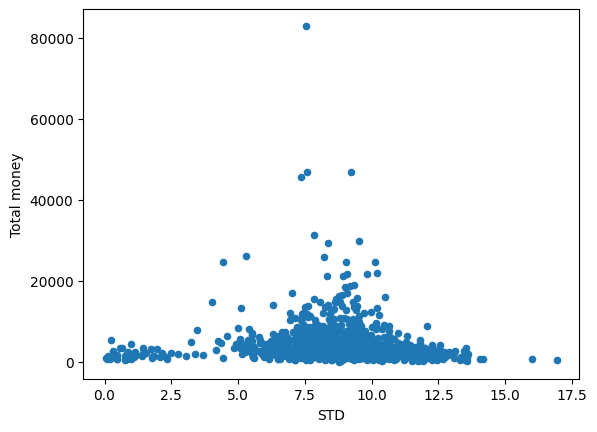

In [ ]:
plt.figure(figsize=(10,10))
# x,y,label = xin_tm_std["hours"],xin_tm_std["金額"], xin_tm_std.index
xin_tm_stdc.plot.scatter(x="hours",y="金額");plt.xlabel("STD");plt.ylabel("Total money")

#加上分線
# plt.vlines(x=xin_tm_stdf["hours"].median(),ymin=0, ymax= 30000,colors="red")
# plt.hlines(y=xin_tm_stdf["金額"].median(), xmin=0, xmax=17.5,colors="red")

In [ ]:
#初步觀察散佈圖後 去除outlier
xin_tm_stdc.sort_values(by = '金額', ascending = False)[:1]
xin_tm_stdc = xin_tm_stdc.drop(xin_tm_stdc[xin_tm_stdc['id'] == 301540].index)

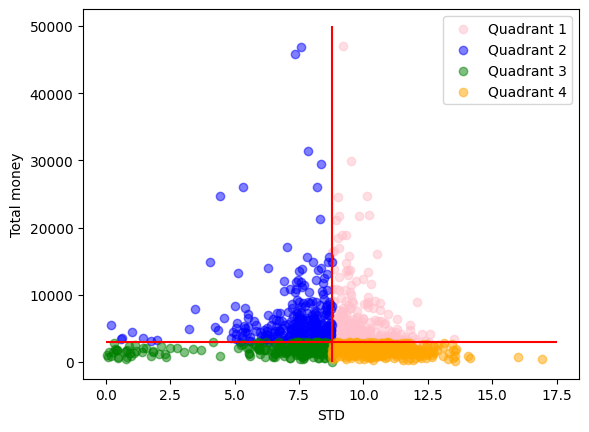

In [ ]:
std_med = xin_tm_stdc["hours"].median()
ttm_med = xin_tm_stdc["金額"].median()

# 將點分為四個區域
xin_tm_stdc['quadrant'] = np.where(xin_tm_stdc['hours'] >= std_med,
                            np.where(xin_tm_stdc['金額'] >= ttm_med, 'Quadrant 1', 'Quadrant 4'),
                            np.where(xin_tm_stdc['金額'] >= ttm_med, 'Quadrant 2', 'Quadrant 3'))

# 繪製四象限圖
fig, ax = plt.subplots()

# 將點繪製為四個區域
colors = {'Quadrant 1': 'pink', 'Quadrant 2': 'blue', 'Quadrant 3': 'green', 'Quadrant 4': 'orange'}
ax.scatter(xin_tm_stdc.loc[xin_tm_stdc['quadrant'] == 'Quadrant 1', 'hours'], xin_tm_stdc.loc[xin_tm_stdc['quadrant'] == 'Quadrant 1', '金額'], color=colors['Quadrant 1'], alpha=0.5, label='Quadrant 1')
ax.scatter(xin_tm_stdc.loc[xin_tm_stdc['quadrant'] == 'Quadrant 2', 'hours'], xin_tm_stdc.loc[xin_tm_stdc['quadrant'] == 'Quadrant 2', '金額'], color=colors['Quadrant 2'], alpha=0.5,label='Quadrant 2')
ax.scatter(xin_tm_stdc.loc[xin_tm_stdc['quadrant'] == 'Quadrant 3', 'hours'], xin_tm_stdc.loc[xin_tm_stdc['quadrant'] == 'Quadrant 3', '金額'], color=colors['Quadrant 3'], alpha=0.5,label='Quadrant 3')
ax.scatter(xin_tm_stdc.loc[xin_tm_stdc['quadrant'] == 'Quadrant 4', 'hours'], xin_tm_stdc.loc[xin_tm_stdc['quadrant'] == 'Quadrant 4', '金額'], color=colors['Quadrant 4'], alpha=0.5,label='Quadrant 4')

#給定x.y標籤 分線及圖例
plt.xlabel("STD");plt.ylabel("Total money")
plt.vlines(x=xin_tm_stdc["hours"].median(),ymin=0, ymax= 50000,colors="red")
plt.hlines(y=xin_tm_stdc["金額"].median(), xmin=0, xmax=17.5,colors="red")
ax.legend()
plt.show()

In [ ]:
xin_tm_stdc["quadrant"].value_counts()

Quadrant 4    286
Quadrant 2    286
Quadrant 3    220
Quadrant 1    220
Name: quadrant, dtype: int64

**三重區**

Text(0, 0.5, 'Total money')

<Figure size 1000x1000 with 0 Axes>

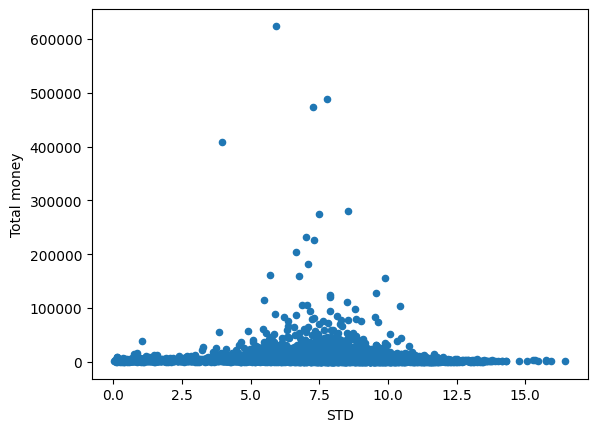

In [ ]:
plt.figure(figsize=(10,10))
triple_tm_stdc.plot.scatter(x="hours",y="金額");plt.xlabel("STD");plt.ylabel("Total money")

In [ ]:
#初步觀察散佈圖後 去除outlier
triple_tm_stdc.sort_values(by = '金額', ascending = False)[:4]
triple_tm_stdc = triple_tm_stdc.drop(triple_tm_stdc[triple_tm_stdc['id'] == 603797].index)
triple_tm_stdc = triple_tm_stdc.drop(triple_tm_stdc[triple_tm_stdc['id'] == 605204].index)
triple_tm_stdc = triple_tm_stdc.drop(triple_tm_stdc[triple_tm_stdc['id'] == 603277].index)
triple_tm_stdc = triple_tm_stdc.drop(triple_tm_stdc[triple_tm_stdc['id'] == 603462].index)

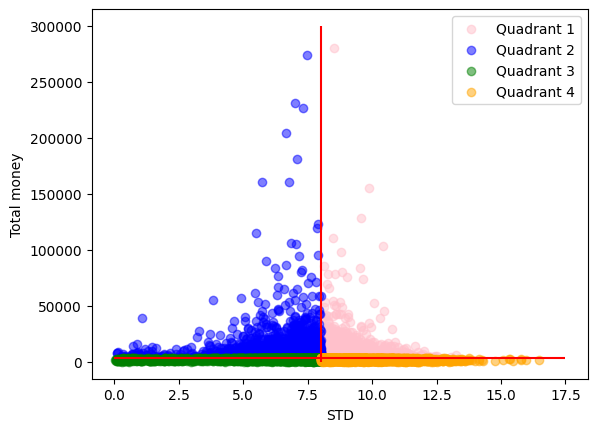

In [ ]:
#象限圖繪製
sstd_med = triple_tm_stdc["hours"].median()
sttm_med = triple_tm_stdc["金額"].median()

# 將點分為四個區域
triple_tm_stdc['quadrant'] = np.where(triple_tm_stdc['hours'] >= sstd_med,
                            np.where(triple_tm_stdc['金額'] >= sttm_med, 'Quadrant 1', 'Quadrant 4'),
                            np.where(triple_tm_stdc['金額'] >= sttm_med, 'Quadrant 2', 'Quadrant 3'))

# 繪製四象限圖
fig, ax = plt.subplots()

# 將點繪製為四個區域
colors = {'Quadrant 1': 'pink', 'Quadrant 2': 'blue', 'Quadrant 3': 'green', 'Quadrant 4': 'orange'}
ax.scatter(triple_tm_stdc.loc[triple_tm_stdc['quadrant'] == 'Quadrant 1', 'hours'], triple_tm_stdc.loc[triple_tm_stdc['quadrant'] == 'Quadrant 1', '金額'], color=colors['Quadrant 1'], alpha=0.5, label='Quadrant 1')
ax.scatter(triple_tm_stdc.loc[triple_tm_stdc['quadrant'] == 'Quadrant 2', 'hours'], triple_tm_stdc.loc[triple_tm_stdc['quadrant'] == 'Quadrant 2', '金額'], color=colors['Quadrant 2'], alpha=0.5,label='Quadrant 2')
ax.scatter(triple_tm_stdc.loc[triple_tm_stdc['quadrant'] == 'Quadrant 3', 'hours'], triple_tm_stdc.loc[triple_tm_stdc['quadrant'] == 'Quadrant 3', '金額'], color=colors['Quadrant 3'], alpha=0.5,label='Quadrant 3')
ax.scatter(triple_tm_stdc.loc[triple_tm_stdc['quadrant'] == 'Quadrant 4', 'hours'], triple_tm_stdc.loc[triple_tm_stdc['quadrant'] == 'Quadrant 4', '金額'], color=colors['Quadrant 4'], alpha=0.5,label='Quadrant 4')

#給定x.y標籤 分線及圖例
plt.xlabel("STD");plt.ylabel("Total money")
plt.vlines(x=triple_tm_stdc["hours"].median(),ymin=0, ymax= 300000,colors="red")
plt.hlines(y=triple_tm_stdc["金額"].median(), xmin=0, xmax=17.5,colors="red")
ax.legend()
plt.show()

In [ ]:
triple_tm_stdc["quadrant"].value_counts()

Quadrant 2    2454
Quadrant 4    2451
Quadrant 1    1956
Quadrant 3    1953
Name: quadrant, dtype: int64

**三多區**

Text(0, 0.5, 'Total money')

<Figure size 1000x1000 with 0 Axes>

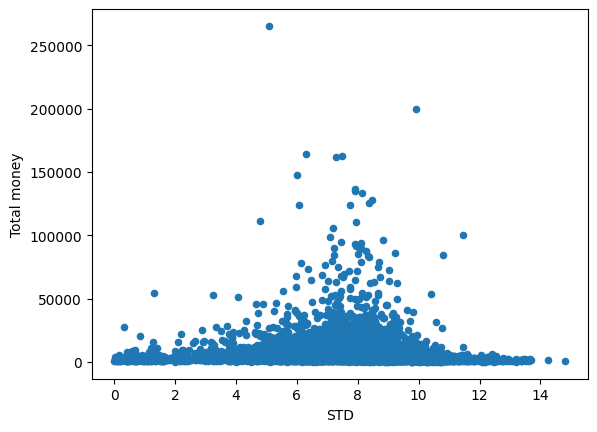

In [ ]:
plt.figure(figsize=(10,10))
more_tm_stdc.plot.scatter(x="hours",y="金額");plt.xlabel("STD");plt.ylabel("Total money")

In [ ]:
#初步觀察散佈圖後 去除outlier
more_tm_stdc.sort_values(by = '金額', ascending = False)[:2]
more_tm_stdc = more_tm_stdc.drop(more_tm_stdc[more_tm_stdc['id'] == 51001222].index)
more_tm_stdc = more_tm_stdc.drop(more_tm_stdc[more_tm_stdc['id'] == 50002258].index)

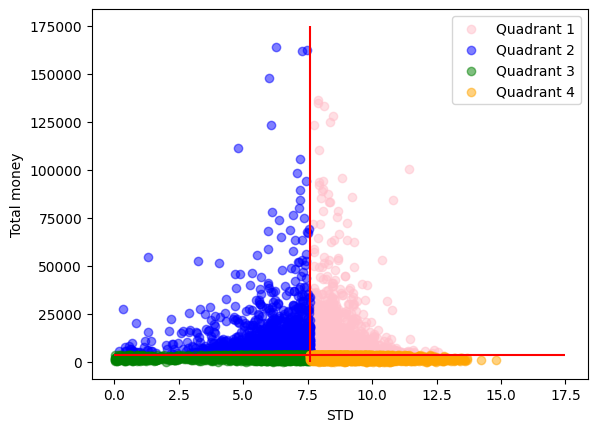

In [ ]:
mstd_med = more_tm_stdc["hours"].median()
mttm_med = more_tm_stdc["金額"].median()

# 將點分為四個區域
more_tm_stdc['quadrant'] = np.where(more_tm_stdc['hours'] >= mstd_med,
                            np.where(more_tm_stdc['金額'] >= mttm_med, 'Quadrant 1', 'Quadrant 4'),
                            np.where(more_tm_stdc['金額'] >= mttm_med, 'Quadrant 2', 'Quadrant 3'))

# 繪製四象限圖
fig, ax = plt.subplots()

# 將點繪製為四個區域
colors = {'Quadrant 1': 'pink', 'Quadrant 2': 'blue', 'Quadrant 3': 'green', 'Quadrant 4': 'orange'}
ax.scatter(more_tm_stdc.loc[more_tm_stdc['quadrant'] == 'Quadrant 1', 'hours'], more_tm_stdc.loc[more_tm_stdc['quadrant'] == 'Quadrant 1', '金額'], color=colors['Quadrant 1'], alpha=0.5, label='Quadrant 1')
ax.scatter(more_tm_stdc.loc[more_tm_stdc['quadrant'] == 'Quadrant 2', 'hours'], more_tm_stdc.loc[more_tm_stdc['quadrant'] == 'Quadrant 2', '金額'], color=colors['Quadrant 2'], alpha=0.5,label='Quadrant 2')
ax.scatter(more_tm_stdc.loc[more_tm_stdc['quadrant'] == 'Quadrant 3', 'hours'], more_tm_stdc.loc[more_tm_stdc['quadrant'] == 'Quadrant 3', '金額'], color=colors['Quadrant 3'], alpha=0.5,label='Quadrant 3')
ax.scatter(more_tm_stdc.loc[more_tm_stdc['quadrant'] == 'Quadrant 4', 'hours'], more_tm_stdc.loc[more_tm_stdc['quadrant'] == 'Quadrant 4', '金額'], color=colors['Quadrant 4'], alpha=0.5,label='Quadrant 4')

#給定x.y標籤 分線及圖例
plt.xlabel("STD");plt.ylabel("Total money")
plt.vlines(x=more_tm_stdc["hours"].median(),ymin=0, ymax= 175000,colors="red")
plt.hlines(y=more_tm_stdc["金額"].median(), xmin=0, xmax=17.5,colors="red")
ax.legend()
plt.show()

In [ ]:
more_tm_stdc["quadrant"].value_counts()

Quadrant 2    2292
Quadrant 4    2291
Quadrant 1    1993
Quadrant 3    1991
Name: quadrant, dtype: int64

In [ ]:
xin_tm_stdc.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/xin_tm_stdc.xlsx',index = False)
triple_tm_stdc.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/sanch_tm_stdc.xlsx',index = False)
more_tm_stdc.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/sanduo_tm_stdc.xlsx',index = False)

OSError: ignored

# **分群後persona**

平均來館次數/來館次數四分位距、平均金額/金額四分位距、每群平均消費力-金額/人數



```
xin_conpow.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/xin_conpow.xlsx',index = False)
triple_conpow.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/triple_conpow.xlsx',index = False)
more_conpow.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/more_conpow.xlsx',index = False)

xin_conpow = pd.read_excel('/content/drive/MyDrive/E7企業專案相關/all_data/xin_conpow.xlsx')
triple_conpow = pd.read_excel('/content/drive/MyDrive/E7企業專案相關/all_data/triple_conpow.xlsx')
more_conpow = pd.read_excel('/content/drive/MyDrive/E7企業專案相關/all_data/more_conpow.xlsx')
```



**新莊區**

**第一群**

In [ ]:
xin_1

In [ ]:
#金額四分位距圖
fig = plt.figure(figsize=(10,10))

money_xin = sns.boxplot(y = xin_1['金額'],showmeans=True,color = "skyblue", width=0.1)

# # 计算四分位数
# q1 = np.percentile(sorted_xin['金額'], 25, axis=1)
# q3 = np.percentile(sorted_xin['金額'], 75, axis=1)
# iqr = q3 - q1

# # 添加四分位距的值和x轴标签
# labels = ['Quadrant 1', 'Quadrant 2', 'Quadrant 3', 'Quadrant 4']
# for i in len(sorted_xin['quadrant'].unique()):
#     ax.text(i + 1, q1[i], f'Q1: {q1[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))
#     ax.text(i + 1, q3[i], f'Q3: {q3[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))
#     ax.text(i + 1, q1[i] - 1.5 * iqr[i], f'Lower Fence: {q1[i] - 1.5 * iqr[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))
#     ax.text(i + 1, q3[i] + 1.5 * iqr[i], f'Upper Fence: {q3[i] + 1.5 * iqr[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))

plt.xlabel("Quadrant0");plt.ylabel("Total money")
plt.show()

**第一群來店次數皆為一次 無法畫次數四分位距圖**

In [ ]:
xin_1_conpow = xin_1['金額'].sum()/len(xin_1["id"].value_counts())
xin_1_conpow

**其他四群**

In [ ]:
# plt.figure(figsize=(10,10))
# xin_tm_stdc.plot.scatter(x="來店次數",y="金額")

# x=xin_tm_stdc["來店次數"]
# y=xin_tm_stdc["金額"]

# # 拟合曲线
# p = np.polyfit(x, y, deg=3)  # 使用一次多项式拟合
# y_fit = np.polyval(p, x)  # 计算拟合曲线的y值

# # 绘制拟合曲线
# plt.plot(x, y_fit, color='red')

# # 添加图例
# plt.legend()
# plt.xlabel("次數");plt.ylabel("Total money")

In [ ]:
# xin_tm_stdc.sort_values(by = '來店次數', ascending = False)[:6]
# xin_tm_stdc = xin_tm_stdc.drop(xin_tm_stdc[xin_tm_stdc['id'] == 301721].index)
# xin_tm_stdc = xin_tm_stdc.drop(xin_tm_stdc[xin_tm_stdc['id'] == 302850].index)
# xin_tm_stdc = xin_tm_stdc.drop(xin_tm_stdc[xin_tm_stdc['id'] == 303118].index)
# xin_tm_stdc = xin_tm_stdc.drop(xin_tm_stdc[xin_tm_stdc['id'] == 302617].index)
# xin_tm_stdc = xin_tm_stdc.drop(xin_tm_stdc[xin_tm_stdc['id'] == 303059].index)
# xin_tm_stdc = xin_tm_stdc.drop(xin_tm_stdc[xin_tm_stdc['id'] == 303718].index)

In [ ]:
# sorted_times = xin_tm_stdc.sort_values('來店次數')
# fig = plt.figure(figsize=(10,15))
# times_xin = sns.boxplot(x=sorted_times['來店次數'] ,y = sorted_times['金額'],showmeans=True,color = "skyblue", width=0.5)
# times_xin = sns.swarmplot(y = sorted_times['金額'] orient = "v", color = "red") #加上資料點
# plt.xlabel("來店次數");plt.ylabel("Total money")
# plt.show()

In [ ]:
sorted_xin = xin_tm_stdc.sort_values('quadrant')
sorted_xin

In [ ]:
#金額四分位距圖
fig = plt.figure(figsize=(10,15))
# xin_sorted = sorted(xin_tm_stdf['quadrant'])
# sorted_labels = sorted(xin_tm_stdf['quadrant'].unique())

money_xin = sns.boxplot(x=sorted_xin['quadrant'] ,y = sorted_xin['金額'],showmeans=True,color = "skyblue", width=0.5)

# # 计算四分位数
# q1 = np.percentile(sorted_xin['金額'], 25, axis=1)
# q3 = np.percentile(sorted_xin['金額'], 75, axis=1)
# iqr = q3 - q1

# # 添加四分位距的值和x轴标签
# labels = ['Quadrant 1', 'Quadrant 2', 'Quadrant 3', 'Quadrant 4']
# for i in len(sorted_xin['quadrant'].unique()):
#     ax.text(i + 1, q1[i], f'Q1: {q1[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))
#     ax.text(i + 1, q3[i], f'Q3: {q3[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))
#     ax.text(i + 1, q1[i] - 1.5 * iqr[i], f'Lower Fence: {q1[i] - 1.5 * iqr[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))
#     ax.text(i + 1, q3[i] + 1.5 * iqr[i], f'Upper Fence: {q3[i] + 1.5 * iqr[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))

plt.xlabel("Quadrant");plt.ylabel("Total money")
plt.show()

In [ ]:
fig = plt.figure(figsize=(10,15))
times_xin = sns.boxplot(x=sorted_xin['quadrant'] ,y = sorted_xin['來店次數'],showmeans=True,color = "skyblue", width=0.5)
plt.xlabel("quadrant");plt.ylabel("times")
plt.show()

In [ ]:
Q1_xin = sorted_xin[sorted_xin["quadrant"]=='Quadrant 1']
Q2_xin = sorted_xin[sorted_xin["quadrant"]=='Quadrant 2']
Q3_xin = sorted_xin[sorted_xin["quadrant"]=='Quadrant 3']
Q4_xin = sorted_xin[sorted_xin["quadrant"]=='Quadrant 4']

xinQ1_conpow = Q1_xin['金額'].sum()/Q1_xin["quadrant"].value_counts()
xinQ2_conpow = Q2_xin['金額'].sum()/Q2_xin["quadrant"].value_counts()
xinQ3_conpow = Q3_xin['金額'].sum()/Q3_xin["quadrant"].value_counts()
xinQ4_conpow = Q4_xin['金額'].sum()/Q4_xin["quadrant"].value_counts()

In [ ]:
print(xinQ1_conpow)
print(xinQ2_conpow)
print(xinQ3_conpow)
print(xinQ4_conpow)
print(xin_1_conpow)

In [ ]:
xin_conpow = {'Quadrant':['Quadrant 0','Quadrant 1','Quadrant 2','Quadrant 3','Quadrant 4'],
              'Conpow':[1278.296666,6810.786559,6673.059545,1816.713636,1749.055997]}

xin_conpow = pd.DataFrame(xin_conpow)
xin_conpow

In [ ]:
import matplotlib.pyplot as plt

colors = plt.cm.get_cmap('viridis', len(xin_conpow))
plt.bar(xin_conpow['Quadrant'], xin_conpow['Conpow'],color=colors(np.arange(len(xin_conpow))))
plt.title("Xinzhuang")
plt.xlabel("Quadrant")
plt.ylabel("Avg consumption")
plt.show()


In [ ]:
print(Q1_xin['來店次數'].sum()/len(Q1_xin))
print(Q2_xin['來店次數'].sum()/len(Q2_xin))
print(Q3_xin['來店次數'].sum()/len(Q3_xin))
print(Q4_xin['來店次數'].sum()/len(Q4_xin))

xin_times = {'Quadrant':['Quadrant 0','Quadrant 1','Quadrant 2','Quadrant 3','Quadrant 4'],
              'times':[1,9.581818,6.902097,2.85,3.094405]}

xin_times = pd.DataFrame(xin_times)

import matplotlib.pyplot as plt

colors = plt.cm.get_cmap('viridis', len(xin_times))
plt.bar(xin_times['Quadrant'], xin_times['times'],color=colors(np.arange(len(xin_times))))
plt.title("Sanchong")
plt.xlabel("Quadrant")
plt.ylabel("Avg times")
plt.show()

**三重區**

**第一群**

In [ ]:
triple_1

In [ ]:
#金額四分位距圖
fig = plt.figure(figsize=(10,10))

money_triple = sns.boxplot(y = triple_1['金額'],showmeans=True,color = "skyblue", width=0.1)

# # 计算四分位数
# q1 = np.percentile(sorted_xin['金額'], 25, axis=1)
# q3 = np.percentile(sorted_xin['金額'], 75, axis=1)
# iqr = q3 - q1

# # 添加四分位距的值和x轴标签
# labels = ['Quadrant 1', 'Quadrant 2', 'Quadrant 3', 'Quadrant 4']
# for i in len(sorted_xin['quadrant'].unique()):
#     ax.text(i + 1, q1[i], f'Q1: {q1[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))
#     ax.text(i + 1, q3[i], f'Q3: {q3[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))
#     ax.text(i + 1, q1[i] - 1.5 * iqr[i], f'Lower Fence: {q1[i] - 1.5 * iqr[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))
#     ax.text(i + 1, q3[i] + 1.5 * iqr[i], f'Upper Fence: {q3[i] + 1.5 * iqr[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))

plt.xlabel("Quadrant0");plt.ylabel("Total money")
plt.show()

**第一群來店次數皆為一次 無法畫次數四分位距圖**

In [ ]:
triple_1_conpow = triple_1['金額'].sum()/len(triple_1["id"].value_counts())

**其他四群**

In [ ]:
sorted_triple = triple_tm_stdc.sort_values('quadrant')

In [ ]:
fig = plt.figure(figsize=(10,15))
money_triple = sns.boxplot(x=sorted_triple['quadrant'] ,y = sorted_triple['金額'],showmeans=True,color = "skyblue", width=0.5)
plt.xlabel("Quadrant");plt.ylabel("Total money")
plt.show()

In [ ]:
fig = plt.figure(figsize=(10,15))
times_triple = sns.boxplot(x=sorted_triple['quadrant'] ,y = sorted_triple['來店次數'],showmeans=True,color = "skyblue", width=0.5)
plt.xlabel("quadrant");plt.ylabel("times")
plt.show()

In [ ]:
Q1_triple = sorted_triple[sorted_triple["quadrant"]=='Quadrant 1']
Q2_triple = sorted_triple[sorted_triple["quadrant"]=='Quadrant 2']
Q3_triple = sorted_triple[sorted_triple["quadrant"]=='Quadrant 3']
Q4_triple = sorted_triple[sorted_triple["quadrant"]=='Quadrant 4']

tripleQ1_conpow = Q1_triple['金額'].sum()/Q1_triple["quadrant"].value_counts()
tripleQ2_conpow = Q2_triple['金額'].sum()/Q2_triple["quadrant"].value_counts()
tripleQ3_conpow = Q3_triple['金額'].sum()/Q3_triple["quadrant"].value_counts()
tripleQ4_conpow = Q4_triple['金額'].sum()/Q4_triple["quadrant"].value_counts()

In [ ]:
print(tripleQ1_conpow)
print(tripleQ2_conpow)
print(tripleQ3_conpow)
print(tripleQ4_conpow)
print(triple_1_conpow)

In [ ]:
triple_conpow = {'Quadrant':['Quadrant 0','Quadrant 1','Quadrant 2','Quadrant 3','Quadrant 4'],
              'Conpow':[2028.776136,9302.307917,10956.394163,2278.411167,2148.922918]}

triple_conpow = pd.DataFrame(triple_conpow)
triple_conpow

In [ ]:
import matplotlib.pyplot as plt

colors = plt.cm.get_cmap('viridis', len(triple_conpow))
plt.bar(triple_conpow['Quadrant'], triple_conpow['Conpow'],color=colors(np.arange(len(triple_conpow))))
plt.title("Sanchong")
plt.xlabel("Quadrant")
plt.ylabel("Avg consumption")
plt.show()

In [ ]:
print(Q1_triple['來店次數'].sum()/len(Q1_triple))
print(Q2_triple['來店次數'].sum()/len(Q2_triple))
print(Q3_triple['來店次數'].sum()/len(Q3_triple))
print(Q4_triple['來店次數'].sum()/len(Q4_triple))

triple_times = {'Quadrant':['Quadrant 0','Quadrant 1','Quadrant 2','Quadrant 3','Quadrant 4'],
              'times':[1,14.982106,11.379380,3.166410,3.662178]}

triple_times = pd.DataFrame(triple_times)

import matplotlib.pyplot as plt

colors = plt.cm.get_cmap('viridis', len(triple_times))
plt.bar(triple_times['Quadrant'], triple_times['times'],color=colors(np.arange(len(triple_times))))
plt.title("Sanchong")
plt.xlabel("Quadrant")
plt.ylabel("Avg times")
plt.show()

**三多區**

**第一群**

In [ ]:
more_1

In [ ]:
#金額四分位距圖
fig = plt.figure(figsize=(10,10))

money_more = sns.boxplot(y = more_1['金額'],showmeans=True,color = "skyblue", width=0.1)

# # 计算四分位数
# q1 = np.percentile(sorted_xin['金額'], 25, axis=1)
# q3 = np.percentile(sorted_xin['金額'], 75, axis=1)
# iqr = q3 - q1

# # 添加四分位距的值和x轴标签
# labels = ['Quadrant 1', 'Quadrant 2', 'Quadrant 3', 'Quadrant 4']
# for i in len(sorted_xin['quadrant'].unique()):
#     ax.text(i + 1, q1[i], f'Q1: {q1[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))
#     ax.text(i + 1, q3[i], f'Q3: {q3[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))
#     ax.text(i + 1, q1[i] - 1.5 * iqr[i], f'Lower Fence: {q1[i] - 1.5 * iqr[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))
#     ax.text(i + 1, q3[i] + 1.5 * iqr[i], f'Upper Fence: {q3[i] + 1.5 * iqr[i]:.2f}', va='center', ha='center', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2'))

plt.xlabel("Quadrant0");plt.ylabel("Total money")
plt.show()

**第一群來店次數皆為一次 無法畫次數四分位距圖**

In [ ]:
more_1_conpow = more_1['金額'].sum()/len(more_1["No"].value_counts())

**其他四群**

In [ ]:
sorted_more = more_tm_stdc.sort_values('quadrant')

In [ ]:
fig = plt.figure(figsize=(10,15))
money_more = sns.boxplot(x=sorted_more['quadrant'] ,y = sorted_more['金額'],showmeans=True,color = "skyblue", width=0.5)
plt.xlabel("Quadrant");plt.ylabel("Total money")
plt.show()

In [ ]:
fig = plt.figure(figsize=(10,15))
times_more = sns.boxplot(x=sorted_more['quadrant'] ,y = sorted_more['來店次數'],showmeans=True,color = "skyblue", width=0.5)
plt.xlabel("quadrant");plt.ylabel("times")
plt.show()

In [ ]:
Q1_more = sorted_more[sorted_more["quadrant"]=='Quadrant 1']
Q2_more = sorted_more[sorted_more["quadrant"]=='Quadrant 2']
Q3_more = sorted_more[sorted_more["quadrant"]=='Quadrant 3']
Q4_more = sorted_more[sorted_more["quadrant"]=='Quadrant 4']

moreQ1_conpow = Q1_more['金額'].sum()/Q1_more["quadrant"].value_counts()
moreQ2_conpow = Q2_more['金額'].sum()/Q2_more["quadrant"].value_counts()
moreQ3_conpow = Q3_more['金額'].sum()/Q3_more["quadrant"].value_counts()
moreQ4_conpow = Q4_more['金額'].sum()/Q4_more["quadrant"].value_counts()


In [ ]:
print(Q1_more['金額'].sum())
print(Q2_more['金額'].sum())
print(Q3_more['金額'].sum())
print(Q4_more['金額'].sum())
print(Q1_more["quadrant"].value_counts())
print(Q2_more["quadrant"].value_counts())
print(len(Q2_more['id']))

In [ ]:
Q1_more

In [ ]:
print(moreQ1_conpow)
print(moreQ2_conpow)
print(moreQ3_conpow)
print(moreQ4_conpow)
print(more_1_conpow)

In [ ]:
more_conpow = {'Quadrant':['Quadrant 0','Quadrant 1','Quadrant 2','Quadrant 3','Quadrant 4'],
              'Conpow':[1863.176506,10770.167584,10194.08726,2342.667002,2108.28852]}

more_conpow = pd.DataFrame(more_conpow)
more_conpow

In [ ]:
import matplotlib.pyplot as plt

colors = plt.cm.get_cmap('viridis', len(more_conpow))
plt.bar(more_conpow['Quadrant'], more_conpow['Conpow'],color=colors(np.arange(len(more_conpow))))
plt.title("Sanduo")
plt.xlabel("Quadrant")
plt.ylabel("Avg consumption")
plt.show()

In [ ]:
print(Q1_more['來店次數'].sum()/len(Q1_more))
print(Q2_more['來店次數'].sum()/len(Q2_more))
print(Q3_more['來店次數'].sum()/len(Q3_more))
print(Q4_more['來店次數'].sum()/len(Q4_more))

more_times = {'Quadrant':['Quadrant 0','Quadrant 1','Quadrant 2','Quadrant 3','Quadrant 4'],
              'times':[1,22.084796,11.359511,3.21597,3.752946]}

more_times = pd.DataFrame(more_times)

import matplotlib.pyplot as plt

colors = plt.cm.get_cmap('viridis', len(more_times))
plt.bar(more_times['Quadrant'], more_times['times'],color=colors(np.arange(len(more_times))))
plt.title("Sanduo")
plt.xlabel("Quadrant")
plt.ylabel("Avg times")
plt.show()

In [ ]:
#xin_conpow.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/xin_conpow.xlsx',index = False)
#triple_conpow.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/triple_conpow.xlsx',index = False)
#more_conpow.to_excel('/content/drive/MyDrive/E7企業專案相關/all_data/more_conpow.xlsx',index = False)

In [ ]:
xin_sum_consum=sorted_xin.groupby(by=['quadrant']).agg({'金額': sum})
triple_sum_consum=sorted_triple.groupby(by=['quadrant']).agg({'金額': sum})
more_sum_consum=sorted_more.groupby(by=['quadrant']).agg({'金額': sum})
# triple_tm = triple.groupby(by=['id']).agg({'金額': sum})
# more_tm = more.groupby(by=['No']).agg({'金額': sum})
# print(sorted_xin.quadrant['金額'].sum())
print(xin_sum_consum)
print(triple_sum_consum)
print(more_sum_consum)

In [ ]:
xin_1['quadrant']='Quadrant 0'
xin_1['來店次數']=1
xin_1 = xin_1.drop('FD', axis=1)
xin_1 = xin_1.drop('LD', axis=1)
xin_1 = xin_1.drop('duration', axis=1)
xin_1 = xin_1.drop('收項時間', axis=1)

triple_1['quadrant']='Quadrant 0'
triple_1['來店次數']=1
triple_1 = triple_1.drop('FD', axis=1)
triple_1 = triple_1.drop('LD', axis=1)
triple_1 = triple_1.drop('duration', axis=1)
triple_1 = triple_1.drop('收項時間', axis=1)
triple_1 = triple_1.drop('單品名稱', axis=1)
triple_1 = triple_1.drop('售單價', axis=1)
triple_1 = triple_1.drop('實單價', axis=1)
triple_1 = triple_1.drop('數量', axis=1)
triple_1 = triple_1.drop('類別名稱', axis=1)

more_1['quadrant']='Quadrant 0'
more_1['來店次數']=1

more_1 = more_1.drop('FD', axis=1)
more_1 = more_1.drop('LD', axis=1)
more_1 = more_1.drop('duration', axis=1)
more_1 = more_1.drop('收項時間', axis=1)

more_1['id']=more_1['No'].rename('id')
more_1 = more_1.drop('No', axis=1)
more_1 = more_1.drop('類別名稱', axis=1)
more_1 = more_1.drop('數量', axis=1)
more_1 = more_1.drop('折扣', axis=1)
more_1 = more_1.drop('來客天數', axis=1)
more_1 = more_1.drop('銷售淨額', axis=1)
more_1 = more_1.drop('折扣級別', axis=1)
more_1 = more_1.drop('有效日期', axis=1)
more_1 = more_1.drop('BD', axis=1)
more_1 = more_1.drop('age', axis=1)
more_1 = more_1.drop('單品名稱', axis=1)
more_1 = more_1.drop('Sexual', axis=1)

xin_new = pd.concat([xin_tm_stdc, xin_1], axis=0)
triple_new = pd.concat([triple_tm_stdc, triple_1], axis=0)
more_new= pd.concat([more_tm_stdc, more_1], axis=0)

In [ ]:
xin_new.to_excel('/content/drive/MyDrive/E7play_pre/xin_new.xlsx',index = False)
triple_new.to_excel('/content/drive/MyDrive/E7play_pre/triple_new.xlsx',index = False)
more_new.to_excel('/content/drive/MyDrive/E7play_pre/more_new.xlsx',index = False)